# 백테스트 모듈

- **A. 종목별 신호검증** (①~⑦): 한 종목당 한 포지션, 신호 품질 확인용
- **B. 포트폴리오 백테스트**: 동시보유 제한·자금배분 + **손절/익절/보유기간/리밸런싱** + **시점별 거래대금 유니버스 필터**
- **C. 그리드서치**: RSI 과매도/과매수 임계값 최적화 (+히트맵)

**실행 순서**: ① → ② → ③ 먼저 실행 후, 원하는 섹션(A/B/C)으로.


## ① 라이브러리

In [1]:
import io, itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
print("numpy", np.__version__, "| pandas", pd.__version__)


numpy 2.0.2 | pandas 2.2.2


## ② CSV 업로드
실행하면 파일 선택창이 뜹니다. 수집한 `krx_ohlcv_*.csv`를 선택하세요.

In [2]:
from google.colab import files
uploaded = files.upload()
FILE = next(iter(uploaded))
print("업로드:", FILE)

# (대안) Google Drive:
# from google.colab import drive; drive.mount('/content/drive')
# FILE = '/content/drive/MyDrive/krx_ohlcv_20160101_20260702.csv'


Saving krx_ohlcv_20160101_20260702.csv to krx_ohlcv_20160101_20260702.csv
업로드: krx_ohlcv_20160101_20260702.csv


## ③ 공통 설정

In [3]:
#@title 공통 파라미터 { run: "auto" }
RSI_PERIOD  = 14   #@param {type:"integer"}
OVERSOLD    = 30   #@param {type:"number"}
OVERBOUGHT  = 70   #@param {type:"number"}
MA_PERIOD   = 200  #@param {type:"integer"}
EXEC        = "next_open"  #@param ["next_open", "close"]
FEE_BUY     = 0.003  #@param {type:"number"}
FEE_SELL    = 0.005  #@param {type:"number"}
MAX_TICKERS = 0    #@param {type:"integer"}
# MA_PERIOD: 국면판단용 이동평균선(일). 종가가 이 선 '이상'일 때만 RSI 매수 진입. 0이면 필터 미사용
print(f"RSI{RSI_PERIOD} | 매수<{OVERSOLD} 매도>{OVERBOUGHT} | MA{MA_PERIOD}선 위에서만 매수 | 체결={EXEC} | 종목제한={MAX_TICKERS or '전체'}")


RSI14 | 매수<30 매도>70 | MA200선 위에서만 매수 | 체결=next_open | 종목제한=전체


## ④ 공통 함수 (데이터 로드, 인디케이터)

In [4]:
def load_df(file, max_tickers=0):
    df = pd.read_csv(file, dtype=str)
    tcol = "ticker" if "ticker" in df.columns else ("code" if "code" in df.columns else None)
    assert tcol, f"티커 컬럼(ticker/code) 없음: {list(df.columns)}"
    df = df.rename(columns={tcol: "ticker"})
    df["date"] = pd.to_datetime(df["date"])
    for c in ["open", "high", "low", "close", "volume"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    if max_tickers > 0:
        keep = sorted(df["ticker"].unique())[:max_tickers]
        df = df[df["ticker"].isin(keep)]
    return df


def wilder_rsi(close, period=14):
    delta = close.diff()
    gain = delta.clip(lower=0.0); loss = -delta.clip(upper=0.0)
    ag = gain.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    al = loss.ewm(alpha=1/period, min_periods=period, adjust=False).mean()
    rsi = 100 - 100/(1 + ag/al)
    rsi = rsi.where(al != 0, 100.0)
    rsi = rsi.where(~((ag == 0) & (al == 0)), 50.0)
    return rsi

print("공통 함수 준비 완료")


공통 함수 준비 완료


---
# A. 종목별 신호검증 백테스트
한 종목당 한 포지션. 매수: RSI<과매도 & 미보유 / 매도: RSI>과매수 & 보유중.

In [5]:
def backtest_one(g, rsi_period, oversold, overbought, exec_mode, fee_buy, fee_sell, ma_period=0):
    g = g.sort_values("date").reset_index(drop=True)
    if len(g) < max(rsi_period, ma_period) + 2:
        return []
    g["rsi"] = wilder_rsi(g["close"], rsi_period)
    if ma_period > 0:
        g["ma"] = g["close"].rolling(ma_period, min_periods=ma_period).mean()
    g["fill"] = g["open"].shift(-1) if exec_mode == "next_open" else g["close"]
    ticker = g["ticker"].iat[0]
    trades = []; in_pos = False; entry_price = entry_date = None
    for i in range(len(g)):
        rsi = g["rsi"].iat[i]
        if np.isnan(rsi): continue
        fill = g["fill"].iat[i]
        if np.isnan(fill) or fill <= 0: continue
        # 국면필터: 종가가 MA선 이상일 때만 매수 (상승국면)
        regime_ok = True
        if ma_period > 0:
            ma = g["ma"].iat[i]
            regime_ok = (not np.isnan(ma)) and (g["close"].iat[i] >= ma)
        if (not in_pos) and rsi < oversold and regime_ok:
            in_pos, entry_price, entry_date = True, fill, g["date"].iat[i]
        elif in_pos and rsi > overbought:
            net = (fill*(1-fee_sell))/(entry_price*(1+fee_buy)) - 1
            trades.append({"ticker":ticker,"entry_date":entry_date,"exit_date":g["date"].iat[i],
                "entry_price":round(entry_price,2),"exit_price":round(fill,2),
                "hold_days":(g["date"].iat[i]-entry_date).days,"ret_net":net,"forced_exit":False})
            in_pos = False
    if in_pos:
        last = g["close"].iat[-1]
        if not np.isnan(last) and last > 0:
            net = (last*(1-fee_sell))/(entry_price*(1+fee_buy)) - 1
            trades.append({"ticker":ticker,"entry_date":entry_date,"exit_date":g["date"].iat[-1],
                "entry_price":round(entry_price,2),"exit_price":round(last,2),
                "hold_days":(g["date"].iat[-1]-entry_date).days,"ret_net":net,"forced_exit":True})
    return trades


def buy_and_hold(g):
    c = g.sort_values("date")["close"].dropna()
    return (c.iloc[-1]/c.iloc[0]-1) if (len(c) >= 2 and c.iloc[0] > 0) else np.nan

# 실행
df = load_df(FILE, MAX_TICKERS)
groups = dict(tuple(df.groupby("ticker")))
tickers = sorted(groups)
all_trades, bh = [], []
for tk in tickers:
    all_trades += backtest_one(groups[tk], RSI_PERIOD, OVERSOLD, OVERBOUGHT, EXEC, FEE_BUY, FEE_SELL, MA_PERIOD)
    b = buy_and_hold(groups[tk])
    if not np.isnan(b): bh.append(b)
assert all_trades, "거래 신호 없음 (임계값/MA기간/기간 확인)"
trades = pd.DataFrame(all_trades).sort_values("exit_date").reset_index(drop=True)

n = len(trades); wins = int((trades["ret_net"]>0).sum())
gwin = trades.loc[trades["ret_net"]>0,"ret_net"].sum(); gloss = -trades.loc[trades["ret_net"]<0,"ret_net"].sum()
pf = gwin/gloss if gloss>0 else float("inf")
per_tk = trades.groupby("ticker")["ret_net"].apply(lambda s:(1+s).prod()-1)
print("="*52); print(f" A. 종목별 신호검증 결과 (MA{MA_PERIOD}선 위에서만 매수)"); print("="*52)
print(f"  총 거래수 {n:,}건 ({trades['ticker'].nunique()}종목) | 승률 {wins/n:.2%}")
print(f"  평균 {trades['ret_net'].mean():.3%} | 중앙값 {trades['ret_net'].median():.3%} | 보유 {trades['hold_days'].mean():.1f}일")
print(f"  Profit Factor {pf:.2f} | 최고 {trades['ret_net'].max():+.2%} / 최저 {trades['ret_net'].min():+.2%}")
print(f"  [전략] 종목평균 누적 {per_tk.mean():+.2%}  vs  [벤치] 단순보유 {np.mean(bh):+.2%}")
print("="*52)
trades.head(10)


 A. 종목별 신호검증 결과 (MA200선 위에서만 매수)
  총 거래수 854건 (457종목) | 승률 63.35%
  평균 5.119% | 중앙값 6.540% | 보유 167.8일
  Profit Factor 1.66 | 최고 +122.13% / 최저 -95.16%
  [전략] 종목평균 누적 +10.47%  vs  [벤치] 단순보유 +156.29%


,ticker,entry_date,exit_date,entry_price,exit_price,hold_days,ret_net,forced_exit
0,001380,2016-10-27,2017-01-09,6531.0,7663.0,74,0.163969,False
1,086790,2017-01-02,2017-02-02,30900.0,35700.0,31,0.146125,False
2,100090,2016-11-04,2017-02-07,7136.0,7859.0,95,0.092533,False
3,005880,2016-10-26,2017-02-17,1700.0,1984.0,114,0.157750,False
4,003520,2016-10-28,2017-02-27,8660.0,8960.0,122,0.026390,False
5,092200,2016-11-02,2017-03-15,8285.0,8502.0,133,0.018007,False
6,058730,2017-02-09,2017-03-16,5710.0,6590.0,35,0.144910,False
7,002140,2017-03-03,2017-03-27,5210.0,8500.0,24,0.618465,False
8,010780,2016-10-31,2017-03-31,49300.0,45650.0,151,-0.081422,False
9,012450,2016-11-01,2017-04-27,51033.0,54395.0,177,0.057377,False


---
# B. 포트폴리오 백테스트 (손절/익절/리밸런싱 + 시점별 유니버스)

- **동시보유 제한** `MAX_POSITIONS`, **자금배분** = 평가자산 ÷ MAX_POSITIONS(균등)
- **청산 규칙**(매일 점검): ①RSI>과매수 ②손절 `STOP_LOSS` ③익절 `TAKE_PROFIT` ④보유기간 `MAX_HOLD_DAYS`
- **리밸런싱 주기** `REBALANCE_DAYS`: N거래일마다 신규매수(청산은 매일)
- **시점별 거래대금 유니버스** `UNIVERSE_TOP`: 각 시점 직전 `LOOKBACK`일 평균 거래대금(≈종가×거래량)
  상위 N종목만 매수 후보 → look-ahead 없이 유동성 필터(생존편향 완화)


In [14]:
#@title 포트폴리오 파라미터 { run: "auto" }
INITIAL_CAPITAL = 10000000  #@param {type:"integer"}
MAX_POSITIONS   = 10        #@param {type:"integer"}
STOP_LOSS       = 0.10      #@param {type:"number"}
TAKE_PROFIT     = 0.20      #@param {type:"number"}
MAX_HOLD_DAYS   = 0         #@param {type:"integer"}
REBALANCE_DAYS  = 30         #@param {type:"integer"}
UNIVERSE_TOP    = 0         #@param {type:"integer"}
LOOKBACK        = 60        #@param {type:"integer"}
# STOP_LOSS/TAKE_PROFIT: 비율(0=미사용). MAX_HOLD_DAYS/UNIVERSE_TOP: 0=미사용. REBALANCE_DAYS: 1=매일
print(f"자본 {INITIAL_CAPITAL:,} | 동시보유 {MAX_POSITIONS} | 손절 {STOP_LOSS:.0%} 익절 {TAKE_PROFIT:.0%} "
      f"| 보유한도 {MAX_HOLD_DAYS or '무제한'} | 리밸 {REBALANCE_DAYS}일 | 유니버스 {UNIVERSE_TOP or '전체'}")


자본 10,000,000 | 동시보유 10 | 손절 10% 익절 20% | 보유한도 무제한 | 리밸 30일 | 유니버스 전체


### B-엔진 (데이터준비 · 시뮬레이션)

In [15]:
def prepare(df, rsi_period, lookback, universe_top, ma_period=0):
    df = df.sort_values(["ticker", "date"]).copy()
    df["rsi"] = df.groupby("ticker")["close"].transform(lambda s: wilder_rsi(s, rsi_period))
    cp = df.pivot(index="date", columns="ticker", values="close").sort_index()
    op = df.pivot(index="date", columns="ticker", values="open").sort_index()
    rp = df.pivot(index="date", columns="ticker", values="rsi").sort_index()
    vp = df.pivot(index="date", columns="ticker", values="volume").sort_index()
    cff = cp.ffill()
    if universe_top and universe_top > 0:
        tv_ma = (cp * vp).rolling(lookback, min_periods=max(5, lookback // 2)).mean()
        IN = (tv_ma.rank(axis=1, ascending=False, method="first") <= universe_top).values
    else:
        IN = None
    if ma_period and ma_period > 0:   # 국면판단용 이동평균선(종목별 종가 SMA)
        df["ma"] = df.groupby("ticker")["close"].transform(
            lambda s: s.rolling(ma_period, min_periods=ma_period).mean())
        MA = df.pivot(index="date", columns="ticker", values="ma").sort_index().values
    else:
        MA = None
    return {"tickers": list(cp.columns), "dates": list(cp.index),
            "O": op.values, "C": cff.values, "R": rp.values, "IN": IN, "MA": MA}


def run_portfolio(prep, oversold, overbought, initial_capital, max_positions,
                  fee_buy, fee_sell, stop_loss=0.0, take_profit=0.0,
                  max_hold_days=0, rebalance_days=1):
    tickers, dates = prep["tickers"], prep["dates"]
    O, C, R, IN, MA = prep["O"], prep["C"], prep["R"], prep["IN"], prep.get("MA")
    n = len(dates); cash = float(initial_capital); holdings = {}; trades = []; eqrec = []
    for i in range(n):
        if i > 0:
            rprev, o, cprev = R[i-1], O[i], C[i-1]
            # 청산(매일): RSI / 손절 / 익절 / 보유기간
            for j in list(holdings):
                pos = holdings[j]; reason = None; pc = cprev[j]
                if not np.isnan(pc) and pos["entry_price"] > 0:
                    chg = pc / pos["entry_price"] - 1
                    if stop_loss > 0 and chg <= -stop_loss: reason = "stop_loss"
                    elif take_profit > 0 and chg >= take_profit: reason = "take_profit"
                if reason is None and rprev[j] > overbought: reason = "rsi"
                if reason is None and max_hold_days > 0 and (dates[i]-pos["entry_date"]).days >= max_hold_days:
                    reason = "max_hold"
                if reason:
                    px = o[j]
                    if np.isnan(px) or px <= 0: continue
                    proceeds = pos["shares"]*px*(1-fee_sell); basis = pos["shares"]*pos["entry_price"]*(1+fee_buy)
                    cash += proceeds; holdings.pop(j)
                    trades.append({"ticker":tickers[j],"entry_date":pos["entry_date"],"exit_date":dates[i],
                        "shares":pos["shares"],"entry_price":round(pos["entry_price"],2),"exit_price":round(px,2),
                        "pnl":proceeds-basis,"ret_net":proceeds/basis-1,"exit_reason":reason,"forced_exit":False})
            # 신규매수: 슬롯/현금/시점별 유니버스 + 국면필터(종가>=MA)
            if rebalance_days <= 1 or i % rebalance_days == 0:
                mtm = sum(holdings[j]["shares"]*C[i,j] for j in holdings if not np.isnan(C[i,j]))
                eqnow = cash + mtm
                if max_positions - len(holdings) > 0:
                    cand = [j for j in np.where(rprev < oversold)[0]
                            if j not in holdings and not np.isnan(o[j]) and o[j] > 0
                            and (IN is None or IN[i-1, j])
                            and (MA is None or (not np.isnan(MA[i-1, j]) and cprev[j] >= MA[i-1, j]))]
                    cand.sort(key=lambda j: rprev[j])   # 더 과매도 우선
                    target = eqnow / max_positions
                    for j in cand:
                        if len(holdings) >= max_positions: break
                        px = o[j]; budget = min(target, cash); sh = int(budget // (px*(1+fee_buy)))
                        if sh <= 0: continue
                        cost = sh*px*(1+fee_buy)
                        if cost > cash + 1e-6: continue
                        cash -= cost; holdings[j] = {"shares":sh,"entry_price":px,"entry_date":dates[i]}
        mtm = sum(holdings[j]["shares"]*C[i,j] for j in holdings if not np.isnan(C[i,j]))
        eqrec.append((dates[i], cash+mtm, cash, len(holdings)))
    # 종료 청산
    for j in list(holdings):
        col = C[:, j]; valid = col[~np.isnan(col)]
        if not valid.size: continue
        px = float(valid[-1]); pos = holdings.pop(j)
        proceeds = pos["shares"]*px*(1-fee_sell); basis = pos["shares"]*pos["entry_price"]*(1+fee_buy); cash += proceeds
        trades.append({"ticker":tickers[j],"entry_date":pos["entry_date"],"exit_date":dates[-1],
            "shares":pos["shares"],"entry_price":round(pos["entry_price"],2),"exit_price":round(px,2),
            "pnl":proceeds-basis,"ret_net":proceeds/basis-1,"exit_reason":"end","forced_exit":True})
    return pd.DataFrame(eqrec, columns=["date","equity","cash","n_pos"]).set_index("date"), pd.DataFrame(trades)


def perf_metrics(eq, initial_capital):
    ret = eq["equity"].pct_change().dropna()
    total = eq["equity"].iloc[-1] / initial_capital - 1
    nd = (eq.index[-1] - eq.index[0]).days
    cagr = (eq["equity"].iloc[-1] / initial_capital) ** (365/nd) - 1 if nd > 0 else float("nan")
    mdd = (eq["equity"] / eq["equity"].cummax() - 1).min()
    sharpe = ret.mean()/ret.std()*np.sqrt(252) if ret.std() > 0 else float("nan")
    return total, cagr, mdd, sharpe

print("포트폴리오 엔진 준비 완료 (MA 국면필터 포함)")


포트폴리오 엔진 준비 완료 (MA 국면필터 포함)


### B-실행 + 성과지표

In [16]:
pdf = load_df(FILE, MAX_TICKERS)
print(f"실행: {pdf['ticker'].nunique()}종목 | {pdf['date'].min().date()}~{pdf['date'].max().date()} ...")
prep = prepare(pdf, RSI_PERIOD, LOOKBACK, UNIVERSE_TOP, MA_PERIOD)
eq, ptrades = run_portfolio(prep, OVERSOLD, OVERBOUGHT, INITIAL_CAPITAL, MAX_POSITIONS,
                            FEE_BUY, FEE_SELL, STOP_LOSS, TAKE_PROFIT, MAX_HOLD_DAYS, REBALANCE_DAYS)
total, cagr, mdd, sharpe = perf_metrics(eq, INITIAL_CAPITAL)
win = (ptrades["ret_net"] > 0).mean() if len(ptrades) else float("nan")

# 동일가중 매수후보유 벤치마크(참고)
cff = pdf.pivot(index="date", columns="ticker", values="close").sort_index().ffill()
base = cff.apply(lambda c: c.dropna().iloc[0] if c.dropna().size else np.nan)
bench = (cff/base).mean(axis=1); bench_eq = INITIAL_CAPITAL*(bench/bench.iloc[0])

print("="*54); print(f" B. 포트폴리오 백테스트 결과 (MA{MA_PERIOD}선 위에서만 매수)"); print("="*54)
print(f"  최종자산 {eq['equity'].iloc[-1]:,.0f}원 | 총수익 {total:+.2%} | CAGR {cagr:+.2%}")
print(f"  MDD {mdd:.2%} | Sharpe {sharpe:.2f} | 거래 {len(ptrades):,}건 | 승률 {win:.1%}")
print(f"  평균 동시보유 {eq['n_pos'].mean():.1f}(최대 {int(eq['n_pos'].max())}) | 평균 현금비중 {(eq['cash']/eq['equity']).mean():.1%}")
if len(ptrades):
    print("  종료사유:", dict(ptrades['exit_reason'].value_counts()))
print(f"  [벤치] 동일가중 보유 총수익 {bench_eq.iloc[-1]/INITIAL_CAPITAL-1:+.2%}")
print("="*54)
ptrades.head(10)


실행: 582종목 | 2016-01-04~2026-07-01 ...
 B. 포트폴리오 백테스트 결과 (MA200선 위에서만 매수)
  최종자산 8,440,770원 | 총수익 -15.59% | CAGR -1.60%
  MDD -20.43% | Sharpe -0.34 | 거래 63건 | 승률 34.9%
  평균 동시보유 0.7(최대 7) | 평균 현금비중 93.0%
  종료사유: {'stop_loss': np.int64(41), 'take_profit': np.int64(14), 'rsi': np.int64(8)}
  [벤치] 동일가중 보유 총수익 +156.29%


,ticker,entry_date,exit_date,shares,entry_price,exit_price,pnl,ret_net,exit_reason,forced_exit
0,029780,2016-11-10,2016-12-05,21,46000.0,41350.0,-104889.750,-0.108257,stop_loss,False
1,003580,2016-12-22,2017-02-06,229,4290.0,3720.0,-137736.630,-0.139783,stop_loss,False
2,007810,2017-08-02,2017-08-18,72,13400.0,16250.0,196455.600,0.203014,take_profit,False
3,003580,2017-09-14,2017-11-09,225,4410.0,3950.0,-110920.500,-0.111452,stop_loss,False
4,012630,2018-06-18,2018-06-20,33,29450.0,26300.0,-111205.050,-0.114084,stop_loss,False
5,028050,2018-06-18,2018-09-28,63,15450.0,18300.0,170865.450,0.175019,rsi,False
6,111770,2018-10-30,2018-11-22,29,33100.0,39950.0,189977.550,0.197322,take_profit,False
7,001530,2018-10-30,2019-01-31,203,4857.0,5223.0,66038.742,0.066778,rsi,False
8,010770,2019-03-14,2019-04-29,175,5770.0,5040.0,-135189.250,-0.133483,stop_loss,False
9,006360,2018-10-30,2019-05-14,23,41800.0,37100.0,-115250.700,-0.119519,stop_loss,False


### B-그래프 + 다운로드

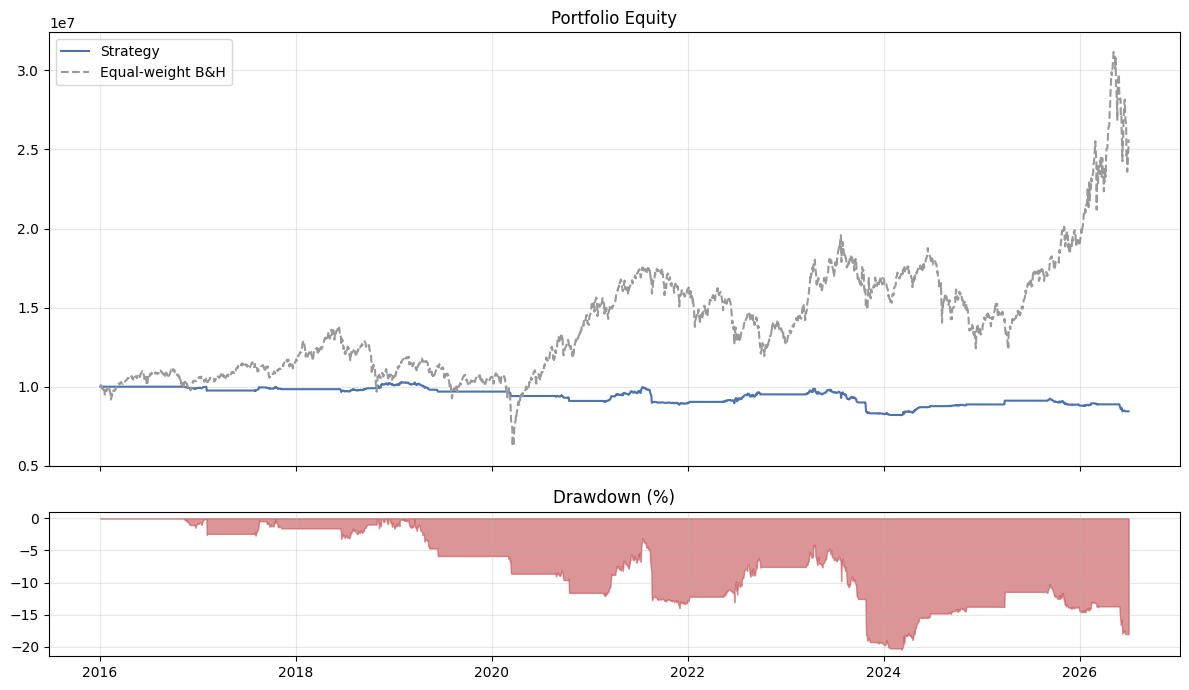

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [17]:
fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios":[3,1]})
ax[0].plot(eq.index, eq["equity"], color="#4C72B0", label="Strategy")
ax[0].plot(bench_eq.index, bench_eq.values, color="#999999", ls="--", label="Equal-weight B&H")
ax[0].set_title("Portfolio Equity"); ax[0].legend(); ax[0].grid(alpha=0.3)
dd = eq["equity"]/eq["equity"].cummax() - 1
ax[1].fill_between(dd.index, dd.values*100, 0, color="#C44E52", alpha=0.6)
ax[1].set_title("Drawdown (%)"); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

from google.colab import files
eq.to_csv("portfolio_equity.csv", encoding="utf-8-sig")
ptrades.to_csv("portfolio_trades.csv", index=False, encoding="utf-8-sig")
files.download("portfolio_equity.csv"); files.download("portfolio_trades.csv")


---
# C. 임계값 그리드서치(최적화)

과매도/과매수 임계값 조합을 전부 백테스트해 최적값을 찾습니다.
데이터준비(`prepare`)는 한 번만 하고 임계값만 바꿔가며 실행하므로 효율적입니다.
손절/익절/유니버스 등 나머지 조건은 **B 섹션 파라미터**를 그대로 사용합니다.

⚠️ 조합 수 × 종목 수만큼 오래 걸립니다. 먼저 ③의 `MAX_TICKERS`로 종목을 줄여 시험하세요.

In [18]:
#@title 그리드 설정 { run: "auto" }
OVERSOLD_GRID   = "20,25,30,35"  #@param {type:"string"}
OVERBOUGHT_GRID = "65,70,75,80"  #@param {type:"string"}
METRIC          = "sharpe"       #@param ["sharpe", "cagr", "total", "mdd"]
os_grid = [float(x) for x in OVERSOLD_GRID.split(",") if x.strip()]
ob_grid = [float(x) for x in OVERBOUGHT_GRID.split(",") if x.strip()]
print("조합수:", sum(1 for a in os_grid for b in ob_grid if a < b), "| 정렬기준:", METRIC)


조합수: 16 | 정렬기준: sharpe


  매수<20 매도>65 : total -1.8% | CAGR -0.2% | MDD -7.6% | Sharpe -0.08 | 15건
  매수<20 매도>70 : total -2.6% | CAGR -0.3% | MDD -7.6% | Sharpe -0.12 | 15건
  매수<20 매도>75 : total -1.9% | CAGR -0.2% | MDD -7.6% | Sharpe -0.09 | 15건
  매수<20 매도>80 : total -2.1% | CAGR -0.2% | MDD -7.6% | Sharpe -0.10 | 15건
  매수<25 매도>65 : total -12.2% | CAGR -1.2% | MDD -25.4% | Sharpe -0.15 | 135건
  매수<25 매도>70 : total -2.3% | CAGR -0.2% | MDD -19.1% | Sharpe 0.01 | 134건
  매수<25 매도>75 : total +7.9% | CAGR +0.7% | MDD -18.7% | Sharpe 0.13 | 133건
  매수<25 매도>80 : total +0.7% | CAGR +0.1% | MDD -19.4% | Sharpe 0.05 | 133건
  매수<30 매도>65 : total +5.2% | CAGR +0.5% | MDD -51.1% | Sharpe 0.11 | 530건
  매수<30 매도>70 : total +7.1% | CAGR +0.7% | MDD -53.6% | Sharpe 0.13 | 497건
  매수<30 매도>75 : total +6.0% | CAGR +0.6% | MDD -52.3% | Sharpe 0.12 | 472건
  매수<30 매도>80 : total -13.2% | CAGR -1.3% | MDD -51.9% | Sharpe 0.00 | 453건
  매수<35 매도>65 : total -6.9% | CAGR -0.7% | MDD -53.4% | Sharpe 0.07 | 764건
  매수<35 매도>70 : total -19.

/tmp/ipykernel_730/2869841429.py:33: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.colorbar(im); plt.tight_layout(); plt.show()
/tmp/ipykernel_730/2869841429.py:33: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  fig.colorbar(im); plt.tight_layout(); plt.show()
/tmp/ipykernel_730/2869841429.py:33: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.colorbar(im); plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: G

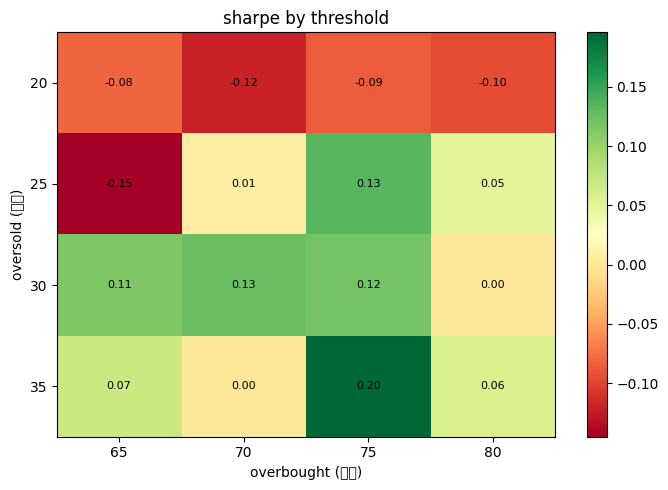

,oversold,overbought,total,cagr,mdd,sharpe,trades
0,35.0,75.0,0.215187,0.018742,-0.539575,0.195964,599
1,25.0,75.0,0.078701,0.007244,-0.186938,0.134654,133
2,30.0,70.0,0.071407,0.006593,-0.536442,0.125274,497
3,30.0,75.0,0.060319,0.005596,-0.523231,0.119793,472
4,30.0,65.0,0.051772,0.004821,-0.511474,0.114047,530
5,35.0,65.0,-0.068691,-0.006757,-0.534102,0.068446,764
6,35.0,80.0,-0.082032,-0.008122,-0.535156,0.057655,586
7,25.0,80.0,0.006968,0.000662,-0.194070,0.048487,133
8,25.0,70.0,-0.022992,-0.002214,-0.191433,0.006912,134
9,30.0,80.0,-0.131522,-0.013345,-0.519142,0.002332,453


In [12]:
gpdf = load_df(FILE, MAX_TICKERS)
gprep = prepare(gpdf, RSI_PERIOD, LOOKBACK, UNIVERSE_TOP, MA_PERIOD)   # RSI/유니버스/MA는 임계값과 무관 → 1회만
rows = []
for a, b in itertools.product(os_grid, ob_grid):
    if a >= b:
        continue
    e, t = run_portfolio(gprep, a, b, INITIAL_CAPITAL, MAX_POSITIONS, FEE_BUY, FEE_SELL,
                         STOP_LOSS, TAKE_PROFIT, MAX_HOLD_DAYS, REBALANCE_DAYS)
    tot, cagr, mdd, shp = perf_metrics(e, INITIAL_CAPITAL)
    rows.append({"oversold": a, "overbought": b, "total": tot, "cagr": cagr,
                 "mdd": mdd, "sharpe": shp, "trades": len(t)})
    print(f"  매수<{a:g} 매도>{b:g} : total {tot:+.1%} | CAGR {cagr:+.1%} | MDD {mdd:.1%} | Sharpe {shp:.2f} | {len(t)}건")

res = pd.DataFrame(rows)
asc = (METRIC == "mdd")   # mdd는 클수록(덜 음수) 좋음 → 오름차순 정렬
res = res.sort_values(METRIC, ascending=asc).reset_index(drop=True)
print("\n최적 조합(Top5, 기준=%s):" % METRIC)
print(res.head(5).to_string(index=False))

# 히트맵
piv = res.pivot(index="oversold", columns="overbought", values=METRIC)
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(piv.values, cmap="RdYlGn", aspect="auto")
ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([f"{c:g}" for c in piv.columns])
ax.set_yticks(range(len(piv.index))); ax.set_yticklabels([f"{r:g}" for r in piv.index])
ax.set_xlabel("overbought (매도)"); ax.set_ylabel("oversold (매수)")
ax.set_title(f"{METRIC} by threshold")
for yy in range(piv.shape[0]):
    for xx in range(piv.shape[1]):
        v = piv.values[yy, xx]
        if not np.isnan(v):
            ax.text(xx, yy, f"{v:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im); plt.tight_layout(); plt.show()
res
